In [1]:
import dask
import time
import toolviper
import random
import webbrowser
import pathlib

#import casatasks as tasks
import toolviper.utils.logger as logger
import toolviper.utils.display as display

import toolviper.dask.client as client

from collections import defaultdict

from xradio.measurement_set import convert_msv2_to_processing_set
from xradio.measurement_set import open_processing_set

import graphviper.graph_tools as graph_tools

In [2]:
client = client.local_client(
    cores=12,
    log_params={
        "log_to_file":False,
        "log_to_term":True,
        "log_level":"INFO" 
    },
    worker_log_params={
        "log_to_file":False,
        "log_to_term":True,
        "log_level":"INFO" 
    }
)

[2026-03-24 11:36:40,675]  WARNING      client:  It is recommended that the local cache directory be set using the dask_local_dir parameter. 
[2026-03-24 11:36:43,985]     INFO      client:  Client <MenrvaClient: 'tcp://127.0.0.1:61578' processes=12 threads=12, memory=14.65 GiB> 


In [3]:
toolviper.utils.data.download(file="absolute_off", folder="data")

[2026-03-24 11:36:43,994]     INFO      client:  Initializing download... 
[2026-03-24 11:36:43,996]     INFO      client:  File already exists: /Users/joshua/Development/toolviper-i42/docs/data/absolute_off 


In [4]:
def generate_delay(n=1, m=2):
    time.sleep(random.uniform(n, m))

In [5]:
def input_imaging_parameters():
    generate_delay(n=1, m=3)
    logger.info("Input image parameters ...")

    
def generate_image(*args, **kwargs):     # I, XX, YY   :: Serial
    logger.info("Generate image ...")
    generate_delay(n=1, m=5)

def set_group(*args, **kwargs):     # I, XX, YY  :: Serial
    logger.info("Set group ...")
    generate_delay(n=1, m=5)

# Distributed #[field, spw, antenna]

def per_imaging_generation(*args, **kwargs):   #[field, spw, antenna] :: Parallel
    #generate_delay(n=1, m=5)
    define_parameters()
    make_grid_table()
    generate_image()   
    calculate_channels()

def define_parameters(*args, **kwargs):
    logger.info("Defing parameters ...")
    logger.debug("[input]::DataTable")
    generate_delay(n=1, m=5)

def per_antenna_image(*args, **kwargs):
    logging.info("Per antenna image ...")
    logger.debug("[input]::MeasurementSet")
    logger.debug("[output]::CASAImage")
    generate_delay(n=1, m=5)

def make_grid_table(*args, **kwargs):    # [XX, YY]
    logger.info("Make grid table ...")
    logger.debug("[input]::DataTable")
    logger.debug("[output]::CASAImage")
    generate_delay(n=1, m=5)
    
def calculate_channels(*args, **kwargs):
    logger.info("Calculate channels ...")
    generate_delay(n=1, m=5)
    
def calculate_image_range(*args, **kwargs):    # [XX, YY]
    logger.info("Calculate image range ...")
    logger.debug("[input]::CASAImage")
    logger.debug("[output]::CASAImage")
    generate_delay(n=1, m=5)


# Distributed #[field, spw]
def combine_per_antenna_stokes(result, *args, **kwargs):  #[field, spw] :: Parallel
    parameter_setup()
    image_combination()
    post_process_parameters()
    grid_table()
    calculate_sensitivity()
    image_examination()
    add_combine_antenna_images()
    qa_score()

def parameter_setup(*args, **kwargs):   
    logger.info("Parameter_setup ...")
    generate_delay(n=1, m=5)

def image_combination(*args, **kwargs):    
    logger.info("Image combination ...")
    logger.debug("[input]::CASAImage")
    logger.debug("[output]::CASAImage Combination")
    generate_delay(n=1, m=5)

def post_process_parameters(*args, **kwargs):    
    logger.info("Postprocess parameters ...")
    logger.debug("[input]::CASAImage Combined")
    generate_delay(n=1, m=5)

def grid_table(*args, **kwargs):    # [XX, YY]
    logger.info("Grid Table ...")
    logger.debug("[input]::DataTable")
    generate_delay(n=1, m=5)

def calculate_sensitivity(*args, **kwargs):  #[field, spw] :: Parallel
    logger.info("Calcualte Sensitivity and Update ...")
    logger.debug("[input]::CASAImage Combined")
    logger.debug("[input]::DataTable")
    logger.debug("[input]::MeasurementSet")
    logger.debug("[input]::MeasurementSet Calibration Tables")
    generate_delay(n=1, m=5)

def image_examination():
    line_detection()
    contamination_detection()
    add_combined_image_list()

def line_detection(*args, **kwargs):    # [XX, YY]
    logger.info("Line Detection ...")
    logger.debug("[input]::CASAImage Conbined")
    logger.debug("[output]::Plot")
    generate_delay(n=1, m=5)

def contamination_detection(*args, **kwargs):    # [XX, YY]
    logger.info("Contamination Detection ...")
    logger.debug("[input]::CASAImage Conbined")
    logger.debug("[output]::Plot")
    generate_delay(n=1, m=5)

def add_combined_image_list(*args, **kwargs):    # [XX, YY]
    logger.info("Add Combined Image to Result List ...")
    generate_delay(n=1, m=5)

def add_combine_antenna_images(*args, **kwargs):    # [XX, YY]
    logger.info("Add Combined Antenna_images XX YY ...")
    logger.debug("[input]::XXYY CASAImage")
    logger.debug("[output]::XXYY CASAImage Combined")
    generate_delay(n=1, m=5)

def qa_score(*args, **kwargs):    # [XX, YY]
    logger.info("Calculating QA Score ...")
    logger.debug("[input]::CASAImage")
    logger.debug("[input]::DataTable")
    logger.debug("[input]::MeasurementSet")
    generate_delay(n=1, m=5)

# Serial Again
def make_weblog_entry():
    logger.info("Making weblog entries ...")
   

In [6]:
#tasks.importasdm(
#    asdm=str(path), 
#    vis="data/absolute_off.ms"
#)

file_path = pathlib.Path().cwd().joinpath("takeshi/uid___A002_Xc1469f_X1c33.ms")
processing_set = pathlib.Path().cwd().joinpath("takeshi/uid___A002_Xc1469f_X1c33.ms.ps.zarr")

if not processing_set.exists():
    convert_msv2_to_processing_set(
        in_file=str(file_path),
        out_file=str(processing_set)
    )


In [7]:
ps = open_processing_set(
    ps_store=str(processing_set),
    scan_intents=["OBSERVE_TARGET#ON_SOURCE"]
)

In [8]:
ps

<xarray.DataTree>
Group: /
│   Attributes:
│       type:     processing_set
├── Group: /uid___A002_Xc1469f_X1c33_65
│   │   Dimensions:                     (time: 76860, antenna_name: 3, frequency: 1,
│   │                                    polarization: 2)
│   │   Coordinates:
│   │     * time                        (time) float64 615kB 1.498e+09 ... 1.498e+09
│   │       field_name                  (time) <U27 8MB dask.array<chunksize=(4804,), meta=np.ndarray>
│   │       scan_name                   (time) <U21 6MB dask.array<chunksize=(4804,), meta=np.ndarray>
│   │     * antenna_name                (antenna_name) <U9 108B 'PM01_T704' ... 'PM04...
│   │       telescope_name              (antenna_name) <U4 48B dask.array<chunksize=(3,), meta=np.ndarray>
│   │     * frequency                   (frequency) float64 8B 8.625e+10
│   │     * polarization                (polarization) <U2 16B 'XX' 'YY'
│   │   Data variables:
│   │       EFFECTIVE_INTEGRATION_TIME  (time, antenna_name) float64 2MB dask.array<chunksize=(76860, 3), meta=np.ndarray>
│   │       FLAG                        (time, antenna_name, frequency, polarization) bool 461kB dask.array<chunksize=(76860, 3, 1, 2), meta=np.ndarray>
│   │       SPECTRUM                    (time, antenna_name, frequency, polarization) float64 4MB dask.array<chunksize=(76860, 3, 1, 2), meta=np.ndarray>
│   │       TIME_CENTROID               (time, antenna_name) float64 2MB dask.array<chunksize=(76860, 3), meta=np.ndarray>
│   │       VISIBILITY_CORRECTED        (time, antenna_name, frequency, polarization) complex128 7MB dask.array<chunksize=(76860, 3, 1, 2), meta=np.ndarray>
│   │       WEIGHT                      (time, antenna_name, frequency, polarization) float64 4MB dask.array<chunksize=(76860, 3, 1, 2), meta=np.ndarray>
│   │   Attributes:
│   │       creation_date:     2026-03-12T07:17:57.188245+00:00
│   │       creator:           {'software_name': 'xradio', 'version': '1.1.2'}
│   │       data_groups:       {'base': {'correlated_data': 'SPECTRUM', 'date': '2026...
│   │       observation_info:  {'execution_block_UID': 'uid://A002/Xc1469f/X1c33', 'o...
│   │       processor_info:    {'sub_type': 'SQUARE_LAW_DETECTOR', 'type': 'RADIOMETER'}
│   │       schema_version:    4.0.0
│   │       type:              spectrum
│   ├── Group: /uid___A002_Xc1469f_X1c33_65/antenna_xds
│   │       Dimensions:                 (antenna_name: 3, cartesian_pos_label: 3,
│   │                                    receptor_label: 2)
│   │       Coordinates:
│   │           mount                   (antenna_name) <U6 72B dask.array<chunksize=(3,), meta=np.ndarray>
│   │           station_name            (antenna_name) <U4 48B dask.array<chunksize=(3,), meta=np.ndarray>
│   │           telescope_name          (antenna_name) <U4 48B dask.array<chunksize=(3,), meta=np.ndarray>
│   │         * cartesian_pos_label     (cartesian_pos_label) <U1 12B 'x' 'y' 'z'
│   │         * receptor_label          (receptor_label) <U5 40B 'pol_0' 'pol_1'
│   │           polarization_type       (antenna_name, receptor_label) <U1 24B dask.array<chunksize=(3, 2), meta=np.ndarray>
│   │       Data variables:
│   │           ANTENNA_DISH_DIAMETER   (antenna_name) float64 24B dask.array<chunksize=(3,), meta=np.ndarray>
│   │           ANTENNA_FOCUS_LENGTH    (antenna_name) float64 24B dask.array<chunksize=(3,), meta=np.ndarray>
│   │           ANTENNA_POSITION        (antenna_name, cartesian_pos_label) float64 72B dask.array<chunksize=(3, 3), meta=np.ndarray>
│   │           ANTENNA_RECEPTOR_ANGLE  (antenna_name, receptor_label) float64 48B dask.array<chunksize=(3, 2), meta=np.ndarray>
│   │       Attributes:
│   │           overall_telescope_name:  ALMA
│   │           relocatable_antennas:    True
│   │           type:                    antenna
│   ├── Group: /uid___A002_Xc1469f_X1c33_65/field_and_source_base_xds
│   │       Dimensions:                           (field_name: 2, sky_dir_label: 2)
│   │       Coordinates:
│  

In [9]:
graph = toolviper.utils.sd.graph.Graph.from_dataset(ps)

[2026-03-24 11:37:04,363]     INFO      client:  Creating graph from dataset ... 


In [10]:
graph.filter(leaves=["uid___A002_Xc1469f_X1c33_65"])

[2026-03-24 11:37:04,365]     INFO      client:  Dropping nodes: {'uid___A002_Xc1469f_X1c33_76', 'uid___A002_Xc1469f_X1c33_73', 'uid___A002_Xc1469f_X1c33_75', 'uid___A002_Xc1469f_X1c33_67', 'uid___A002_Xc1469f_X1c33_66', 'uid___A002_Xc1469f_X1c33_70', 'uid___A002_Xc1469f_X1c33_72', 'uid___A002_Xc1469f_X1c33_71', 'uid___A002_Xc1469f_X1c33_68', 'uid___A002_Xc1469f_X1c33_74', 'uid___A002_Xc1469f_X1c33_77', 'uid___A002_Xc1469f_X1c33_69'} 


In [11]:
graph.datatree

<xarray.DataTree>
Group: /
│   Attributes:
│       type:     processing_set
└── Group: /uid___A002_Xc1469f_X1c33_65
    │   Dimensions:                     (time: 76860, antenna_name: 3, frequency: 1,
    │                                    polarization: 2)
    │   Coordinates:
    │     * time                        (time) float64 615kB 1.498e+09 ... 1.498e+09
    │       field_name                  (time) <U27 8MB dask.array<chunksize=(4804,), meta=np.ndarray>
    │       scan_name                   (time) <U21 6MB dask.array<chunksize=(4804,), meta=np.ndarray>
    │     * antenna_name                (antenna_name) <U9 108B 'PM01_T704' ... 'PM04...
    │       telescope_name              (antenna_name) <U4 48B dask.array<chunksize=(3,), meta=np.ndarray>
    │     * frequency                   (frequency) float64 8B 8.625e+10
    │     * polarization                (polarization) <U2 16B 'XX' 'YY'
    │   Data variables:
    │       EFFECTIVE_INTEGRATION_TIME  (time, antenna_name) float64 2MB dask.array<chunksize=(76860, 3), meta=np.ndarray>
    │       FLAG                        (time, antenna_name, frequency, polarization) bool 461kB dask.array<chunksize=(76860, 3, 1, 2), meta=np.ndarray>
    │       SPECTRUM                    (time, antenna_name, frequency, polarization) float64 4MB dask.array<chunksize=(76860, 3, 1, 2), meta=np.ndarray>
    │       TIME_CENTROID               (time, antenna_name) float64 2MB dask.array<chunksize=(76860, 3), meta=np.ndarray>
    │       VISIBILITY_CORRECTED        (time, antenna_name, frequency, polarization) complex128 7MB dask.array<chunksize=(76860, 3, 1, 2), meta=np.ndarray>
    │       WEIGHT                      (time, antenna_name, frequency, polarization) float64 4MB dask.array<chunksize=(76860, 3, 1, 2), meta=np.ndarray>
    │   Attributes:
    │       creation_date:     2026-03-12T07:17:57.188245+00:00
    │       creator:           {'software_name': 'xradio', 'version': '1.1.2'}
    │       data_groups:       {'base': {'correlated_data': 'SPECTRUM', 'date': '2026...
    │       observation_info:  {'execution_block_UID': 'uid://A002/Xc1469f/X1c33', 'o...
    │       processor_info:    {'sub_type': 'SQUARE_LAW_DETECTOR', 'type': 'RADIOMETER'}
    │       schema_version:    4.0.0
    │       type:              spectrum
    ├── Group: /uid___A002_Xc1469f_X1c33_65/antenna_xds
    │       Dimensions:                 (antenna_name: 3, cartesian_pos_label: 3,
    │                                    receptor_label: 2)
    │       Coordinates:
    │           mount                   (antenna_name) <U6 72B dask.array<chunksize=(3,), meta=np.ndarray>
    │           station_name            (antenna_name) <U4 48B dask.array<chunksize=(3,), meta=np.ndarray>
    │           telescope_name          (antenna_name) <U4 48B dask.array<chunksize=(3,), meta=np.ndarray>
    │         * cartesian_pos_label     (cartesian_pos_label) <U1 12B 'x' 'y' 'z'
    │         * receptor_label          (receptor_label) <U5 40B 'pol_0' 'pol_1'
    │           polarization_type       (antenna_name, receptor_label) <U1 24B dask.array<chunksize=(3, 2), meta=np.ndarray>
    │       Data variables:
    │           ANTENNA_DISH_DIAMETER   (antenna_name) float64 24B dask.array<chunksize=(3,), meta=np.ndarray>
    │           ANTENNA_FOCUS_LENGTH    (antenna_name) float64 24B dask.array<chunksize=(3,), meta=np.ndarray>
    │           ANTENNA_POSITION        (antenna_name, cartesian_pos_label) float64 72B dask.array<chunksize=(3, 3), meta=np.ndarray>
    │           ANTENNA_RECEPTOR_ANGLE  (antenna_name, receptor_label) float64 48B dask.array<chunksize=(3, 2), meta=np.ndarray>
    │       Attributes:
    │           overall_telescope_name:  ALMA
    │           relocatable_antennas:    True
    │           type:                    antenna
    ├── Group: /uid___A002_Xc1469f_X1c33_65/field_and_source_base_xds
    │       Dimensions:                           (field_name: 2, sky_dir_label: 2)
    │       Coordinates:
   

In [12]:
graph.make_coordinates(coords=["antenna_name", "field_name"])

[2026-03-24 11:37:04,452]     INFO      client:  Making antenna coordinate ... 
[2026-03-24 11:37:04,650]     INFO      client:  Making field coordinate ... 


In [13]:
graph.coordinates

In [14]:
graph.build_node(ps_partition = ["spectral_window_name", "field_name"])

In [15]:
graph.node_mapping

In [16]:
graph.map(function=per_imaging_generation, parameters={"parameter": True}, connect=None)
graph.reduce(parameters={"parameter": True}, function=combine_per_antenna_stokes, mode="single_node")

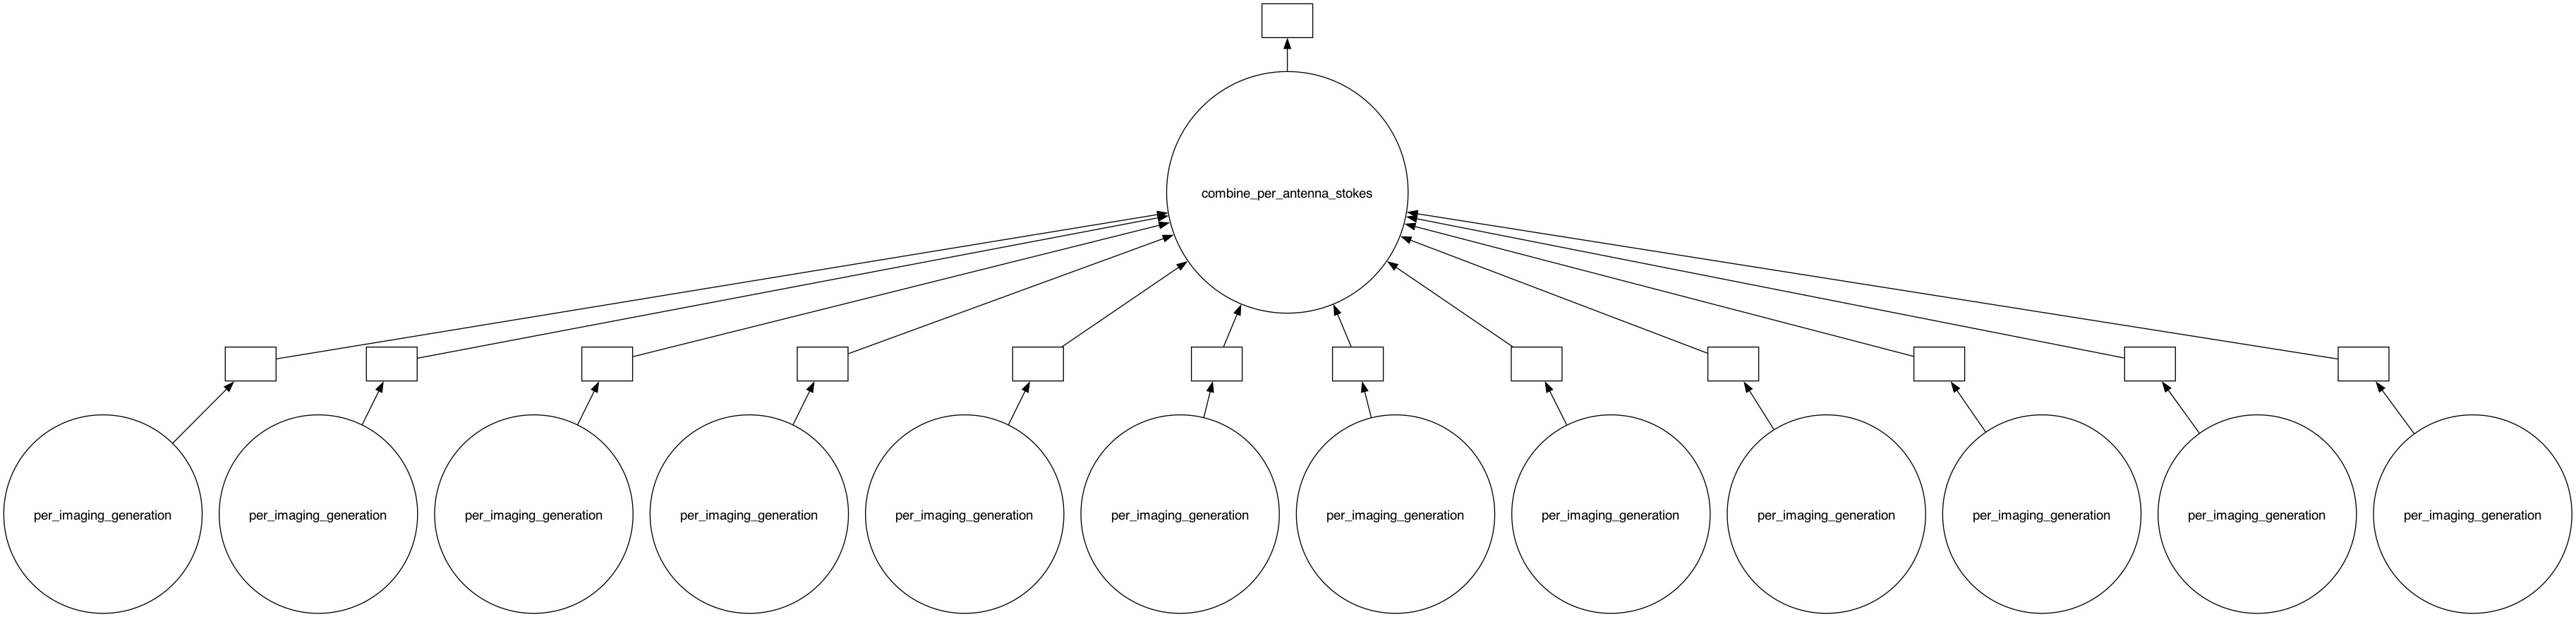

In [17]:
dask.visualize(graph._graph, filename="map_graph")

In [18]:
graph.reset()

In [19]:
# Spawn dashboard window in a seperate tab,
# comment out if you don't want this to spawn.
webbrowser.open(url=client.dashboard_link)

def hsd_imaging(processing_set):
    # Serial processing
    input_imaging_parameters()
    generate_image()
    set_group()

    # Begin Preprocessing
    ps = open_processing_set(
        ps_store=str(processing_set),
        scan_intents=["OBSERVE_TARGET#ON_SOURCE"]
    )

    job = toolviper.utils.sd.graph.Graph.from_dataset(ps)

    # If you want to filter sub-dataset
    job.filter(leaves=["uid___A002_Xc1469f_X1c33_65"])

    # We are actually doing [field, spw, antenna] here but the processing set is already split up by spw.
    job.make_coordinates(coords=["antenna_name", "field_name"])
    job.build_node(ps_partition = ["spectral_window_name", "field_name"])
    
    # Start Dask processing - building job graph
    job.map(function=per_imaging_generation, parameters={"parameter": True}, connect=None)
    job.reduce(parameters={"parameter": True}, function=combine_per_antenna_stokes, mode="single_node")

    # Finish Dask processing - compute job graph
    job.compute()
    
    make_weblog_entry()
    

In [20]:
#dask.compute(graph.graph)

hsd_imaging(processing_set=processing_set)

[2026-03-24 11:37:08,485]     INFO      client:  Input image parameters ... 
[2026-03-24 11:37:08,486]     INFO      client:  Generate image ... 
[2026-03-24 11:37:09,844]     INFO      client:  Set group ... 
[2026-03-24 11:37:32,408]     INFO      client:  Creating graph from dataset ... 
[2026-03-24 11:37:32,408]     INFO      client:  Dropping nodes: {'uid___A002_Xc1469f_X1c33_76', 'uid___A002_Xc1469f_X1c33_73', 'uid___A002_Xc1469f_X1c33_75', 'uid___A002_Xc1469f_X1c33_67', 'uid___A002_Xc1469f_X1c33_66', 'uid___A002_Xc1469f_X1c33_70', 'uid___A002_Xc1469f_X1c33_72', 'uid___A002_Xc1469f_X1c33_71', 'uid___A002_Xc1469f_X1c33_68', 'uid___A002_Xc1469f_X1c33_74', 'uid___A002_Xc1469f_X1c33_77', 'uid___A002_Xc1469f_X1c33_69'} 
[2026-03-24 11:37:32,454]     INFO      client:  Making antenna coordinate ... 
[2026-03-24 11:37:32,816]     INFO      client:  Making field coordinate ... 
[2026-03-24 11:37:33,599]     INFO    worker_0:  Defing parameters ... 
[2026-03-24 11:37:33,600]     INFO    w

In [21]:
client.close()

In [22]:
#keys = list(arguments.keys())
#inputs = [dict(zip(axes, combo)) for combo in itertools.product(*arguments.values())]
#inputs

In [23]:
#import itertools

#axes = ["spw", "antenna"]
#arguments = {axis: data.coords[axis].values for axis in axes}